# Introduction to Machine Learning — Class 9
## Artificial Neural Networks & Backpropagation

**Input dataset:** `adult_classification_v1.csv`  
**Problem:** Binary classification  

---

### Learning goals
- Understand neural networks as nonlinear classifiers
- Relate ANN concepts to previous models
- Understand the role of activation functions
- Interpret the cost function and backpropagation conceptually
- Reflect on when neural networks are (and are not) appropriate

> **Key idea:** Neural networks learn representations, not just decision boundaries.

<div style="margin-left: 2em; font-size: 0.9em; font-style: italic;">
An AI language model (ChatGPT by OpenAI) was used to support the creation of practical class materials. 
All arguments, outputs, and final wording were critically reviewed, edited, and validated by the author 
prior to use with students.
</div>

## 0. Data context

You will continue using the **same dataset** used throughout the supervised learning block.

The goal is **not** to outperform previous models, but to:
- understand what changes conceptually
- compare complexity, interpretability, and performance


In [1]:
DATA_PATH = "adult_classification_v1.csv"


## 1. Imports


In [2]:
# TODO: import required libraries
# numpy, pandas, matplotlib
# sklearn: train_test_split
# sklearn.neural_network: MLPClassifier
# sklearn.metrics: accuracy_score, balanced_accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.preprocessing import StandardScaler


In [3]:
# Auto-check
import importlib
_required = ["numpy", "pandas", "sklearn"]
missing = [m for m in _required if importlib.util.find_spec(m) is None]
assert not missing, f"Missing packages: {missing}"
print("Auto-check passed.")


Auto-check passed.


## 2. Load data and split

### Tasks
- Load the dataset
- Split into training and validation sets
- Reflect on the need for data scaling


In [4]:
# TODO: load dataset and split
df = pd.read_csv(DATA_PATH)

# Assuming last column is target — adjust if needed
X = df.drop(columns=["income"])   # or whatever your target column is
y = df["income"]

# Encode categoricals if not already done
X = pd.get_dummies(X)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale — fit ONLY on train, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

print(f"Train: {X_train.shape}, Val: {X_val.shape}")

Train: (36177, 62), Val: (9045, 62)


## 3. Baseline reminder

### Task
- Train a simple baseline model (e.g. Logistic Regression)
- Record its performance for comparison


In [5]:
# TODO: baseline model
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_val_scaled)

print("=== Logistic Regression ===")
print(f"Accuracy:          {accuracy_score(y_val, y_pred_lr):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_val, y_pred_lr):.4f}")

=== Logistic Regression ===
Accuracy:          0.8458
Balanced Accuracy: 0.7644


## 4. Artificial Neural Network

An ANN is composed of:
- layers
- neurons
- weights
- activation functions

### Tasks
- Train a simple neural network
- Compare performance with baseline

**Reflection**
- Is the improvement significant?


In [6]:
# TODO: neural network model
# Example: MLPClassifier(hidden_layer_sizes=(...), activation="relu")
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # 2 hidden layers: 64 then 32 neurons
    activation="relu",
    max_iter=300,
    random_state=42,
    verbose=False
)
mlp.fit(X_train_scaled, y_train)

y_pred_mlp = mlp.predict(X_val_scaled)

print("=== MLP Classifier ===")
print(f"Accuracy:          {accuracy_score(y_val, y_pred_mlp):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_val, y_pred_mlp):.4f}")

=== MLP Classifier ===
Accuracy:          0.8339
Balanced Accuracy: 0.7609


In [16]:
def eval_model(name, model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    
    y_pred_train = model.predict(X_train)
    y_pred_val   = model.predict(X_val)
    
    acc_train  = accuracy_score(y_train, y_pred_train)
    acc_val    = accuracy_score(y_val,   y_pred_val)
    bacc_train = balanced_accuracy_score(y_train, y_pred_train)
    bacc_val   = balanced_accuracy_score(y_val,   y_pred_val)
    
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  {'':25s}  {'Train':>8}  {'Val':>8}")
    print(f"  {'Accuracy':25s}  {acc_train:>8.4f}  {acc_val:>8.4f}")
    print(f"  {'Balanced Accuracy':25s}  {bacc_train:>8.4f}  {bacc_val:>8.4f}")
    
    # Overfitting warning
    if acc_train - acc_val > 0.05:
        print(f"  ⚠️  Possible overfitting (gap = {acc_train - acc_val:.3f})")
    
    return {"name": name, "acc_val": acc_val, "bacc_val": bacc_val,
            "acc_train": acc_train, "bacc_train": bacc_train}

In [18]:
results = []

# Shared fast settings — no learning_rate_init here
FAST = dict(
    solver="adam",
    max_iter=100,
    early_stopping=True,
    n_iter_no_change=10,
    tol=1e-3,
    random_state=42
)

DEFAULT_LR = 0.001  # adam default — used explicitly everywhere

# --- Architecture experiments ---

results.append(eval_model(
    "Shallow — (32,)",
    MLPClassifier(hidden_layer_sizes=(32,), activation="relu",
                  learning_rate_init=DEFAULT_LR, **FAST),
    X_train_scaled, y_train, X_val_scaled, y_val
))

results.append(eval_model(
    "Wide — (256,)",
    MLPClassifier(hidden_layer_sizes=(256,), activation="relu",
                  learning_rate_init=DEFAULT_LR, **FAST),
    X_train_scaled, y_train, X_val_scaled, y_val
))

results.append(eval_model(
    "Deep narrow — (32, 32, 32)",
    MLPClassifier(hidden_layer_sizes=(32, 32, 32), activation="relu",
                  learning_rate_init=DEFAULT_LR, **FAST),
    X_train_scaled, y_train, X_val_scaled, y_val
))

results.append(eval_model(
    "Funnel — (128, 64, 32)",
    MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation="relu",
                  learning_rate_init=DEFAULT_LR, **FAST),
    X_train_scaled, y_train, X_val_scaled, y_val
))

results.append(eval_model(
    "Very deep — (128, 64, 32, 16, 8)",
    MLPClassifier(hidden_layer_sizes=(128, 64, 32, 16, 8), activation="relu",
                  learning_rate_init=DEFAULT_LR, **FAST),
    X_train_scaled, y_train, X_val_scaled, y_val
))

# --- Regularisation ---

results.append(eval_model(
    "Regularised — alpha=0.01",
    MLPClassifier(hidden_layer_sizes=(128, 64), activation="relu",
                  alpha=0.01, learning_rate_init=DEFAULT_LR, **FAST),
    X_train_scaled, y_train, X_val_scaled, y_val
))

results.append(eval_model(
    "Heavy regularisation — alpha=0.1",
    MLPClassifier(hidden_layer_sizes=(128, 64), activation="relu",
                  alpha=0.1, learning_rate_init=DEFAULT_LR, **FAST),
    X_train_scaled, y_train, X_val_scaled, y_val
))

# --- Solver / Learning rate ---
FAST_SGD = {**FAST, "solver": "sgd"}

results.append(eval_model(
    "Solver: sgd",
    MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu",
                  learning_rate_init=0.01, **FAST_SGD),
    X_train_scaled, y_train, X_val_scaled, y_val
))

results.append(eval_model(
    "Solver: adam (default lr)",
    MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu",
                  learning_rate_init=DEFAULT_LR, **FAST),
    X_train_scaled, y_train, X_val_scaled, y_val
))

results.append(eval_model(
    "Fast learning rate — lr=0.01",
    MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu",
                  learning_rate_init=0.01, **FAST),
    X_train_scaled, y_train, X_val_scaled, y_val
))

results.append(eval_model(
    "Slow learning rate — lr=0.0001",
    MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu",
                  learning_rate_init=0.0001, **FAST),
    X_train_scaled, y_train, X_val_scaled, y_val
))


  Shallow — (32,)
                                Train       Val
  Accuracy                     0.8593    0.8479
  Balanced Accuracy            0.7899    0.7752

  Wide — (256,)
                                Train       Val
  Accuracy                     0.8618    0.8506
  Balanced Accuracy            0.7872    0.7733

  Deep narrow — (32, 32, 32)
                                Train       Val
  Accuracy                     0.8585    0.8477
  Balanced Accuracy            0.7937    0.7788

  Funnel — (128, 64, 32)
                                Train       Val
  Accuracy                     0.8690    0.8461
  Balanced Accuracy            0.8009    0.7673

  Very deep — (128, 64, 32, 16, 8)
                                Train       Val
  Accuracy                     0.8698    0.8451
  Balanced Accuracy            0.8191    0.7840

  Regularised — alpha=0.01
                                Train       Val
  Accuracy                     0.8578    0.8478
  Balanced Accuracy         

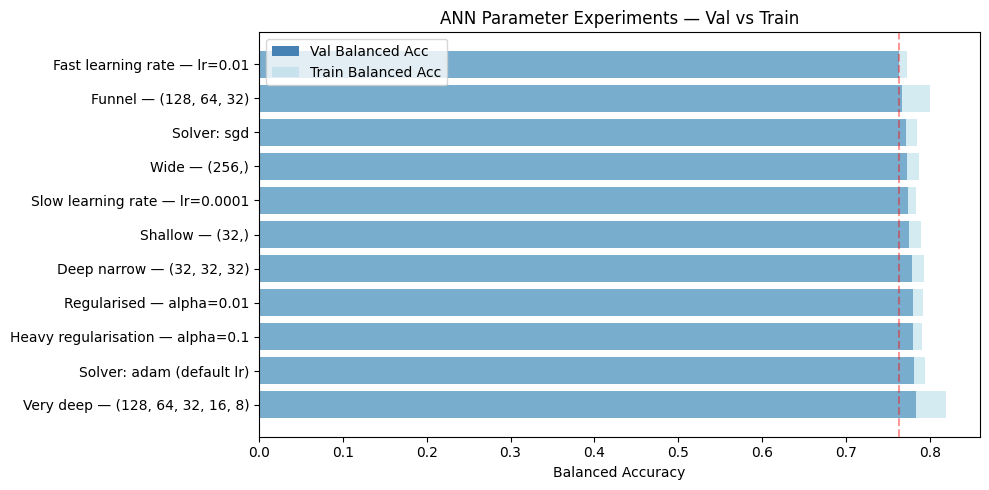


📊 Ranked by Validation Balanced Accuracy:
                            name  bacc_train  bacc_val
Very deep — (128, 64, 32, 16, 8)    0.819135  0.783995
       Solver: adam (default lr)    0.794479  0.781839
Heavy regularisation — alpha=0.1    0.791399  0.780217
        Regularised — alpha=0.01    0.792072  0.779928
      Deep narrow — (32, 32, 32)    0.793727  0.778808
                 Shallow — (32,)    0.789905  0.775217
  Slow learning rate — lr=0.0001    0.783800  0.773800
                   Wide — (256,)    0.787221  0.773316
                     Solver: sgd    0.784745  0.772204
          Funnel — (128, 64, 32)    0.800878  0.767312
    Fast learning rate — lr=0.01    0.772910  0.763144


In [19]:
df_results = pd.DataFrame(results).sort_values("bacc_val", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(df_results))
width = 0.35

ax.barh([r["name"] for r in df_results.to_dict("records")],
        df_results["bacc_val"], color="steelblue", label="Val Balanced Acc")
ax.barh([r["name"] for r in df_results.to_dict("records")],
        df_results["bacc_train"], color="lightblue", alpha=0.5,
        label="Train Balanced Acc")

ax.set_xlabel("Balanced Accuracy")
ax.set_title("ANN Parameter Experiments — Val vs Train")
ax.legend()
ax.axvline(x=df_results["bacc_val"].iloc[-1], color="red",
           linestyle="--", alpha=0.4, label="worst val")
plt.tight_layout()
plt.show()

print("\n📊 Ranked by Validation Balanced Accuracy:")
print(df_results[["name", "bacc_train", "bacc_val"]].to_string(index=False))

## 5. Activation functions

### Task
- Experiment with different activation functions
- Observe convergence and performance

**Reflection**
- Why are nonlinear activations important?


In [ ]:
import time

activations = ["relu", "tanh", "logistic", "identity"]
results_act = []

for act in activations:
    model = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation=act,
        max_iter=300,
        random_state=42
    )
    
    start = time.time()
    result = eval_model(
        f"Activation: {act}",
        model,
        X_train_scaled, y_train,
        X_val_scaled, y_val
    )
    elapsed = time.time() - start
    
    result["activation"] = act
    result["time_s"] = round(elapsed, 3)
    result["n_iter"] = model.n_iter_          # how many epochs it actually ran
    result["converged"] = model.n_iter_ < 300 # did it converge before max_iter?
    results_act.append(result)
    print(f"  ⏱️  Time: {elapsed:.3f}s | Epochs: {model.n_iter_} | Converged: {model.n_iter_ < 300}")


  Activation: relu
                                Train       Val
  Accuracy                     0.8994    0.8339
  Balanced Accuracy            0.8503    0.7609
  ⚠️  Possible overfitting (gap = 0.065)
  ⏱️  Time: 292.567s | Epochs: 239 | Converged: True


C:\Users\dinis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(



  Activation: tanh
                                Train       Val
  Accuracy                     0.9234    0.8218
  Balanced Accuracy            0.8899    0.7553
  ⚠️  Possible overfitting (gap = 0.102)
  ⏱️  Time: 353.160s | Epochs: 300 | Converged: False


C:\Users\dinis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(



  Activation: logistic
                                Train       Val
  Accuracy                     0.8908    0.8325
  Balanced Accuracy            0.8448    0.7689
  ⚠️  Possible overfitting (gap = 0.058)
  ⏱️  Time: 535.525s | Epochs: 300 | Converged: False

  Activation: identity
                                Train       Val
  Accuracy                     0.8490    0.8461
  Balanced Accuracy            0.7707    0.7669
  ⏱️  Time: 35.364s | Epochs: 48 | Converged: True


In [ ]:
import time

activations = ["relu", "tanh", "logistic", "identity"]
results_act = []

for act in activations:
    model = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation=act,
        solver="adam",
        learning_rate_init=0.001,
        max_iter=100,
        early_stopping=True,
        n_iter_no_change=10,
        tol=1e-3,
        random_state=42
    )

    start = time.time()
    result = eval_model(
        f"Activation: {act}",
        model,
        X_train_scaled, y_train,
        X_val_scaled, y_val
    )
    elapsed = time.time() - start
    
    result["activation"] = act
    result["time_s"] = round(elapsed, 3)
    result["n_iter"] = model.n_iter_          # how many epochs it actually ran
    result["converged"] = model.n_iter_ < 300 # did it converge before max_iter?
    results_act.append(result)
    print(f"  ⏱️  Time: {elapsed:.3f}s | Epochs: {model.n_iter_} | Converged: {model.n_iter_ < 300}")

In [10]:
df_act = pd.DataFrame(results_act)[["activation", "bacc_val", "time_s", "n_iter", "converged"]]
df_act = df_act.sort_values("bacc_val", ascending=False)
print(df_act.to_string(index=False))

activation  bacc_val  time_s  n_iter  converged
  logistic  0.768888 535.525     300      False
  identity  0.766864  35.364      48       True
      relu  0.760872 292.567     239       True
      tanh  0.755330 353.160     300      False


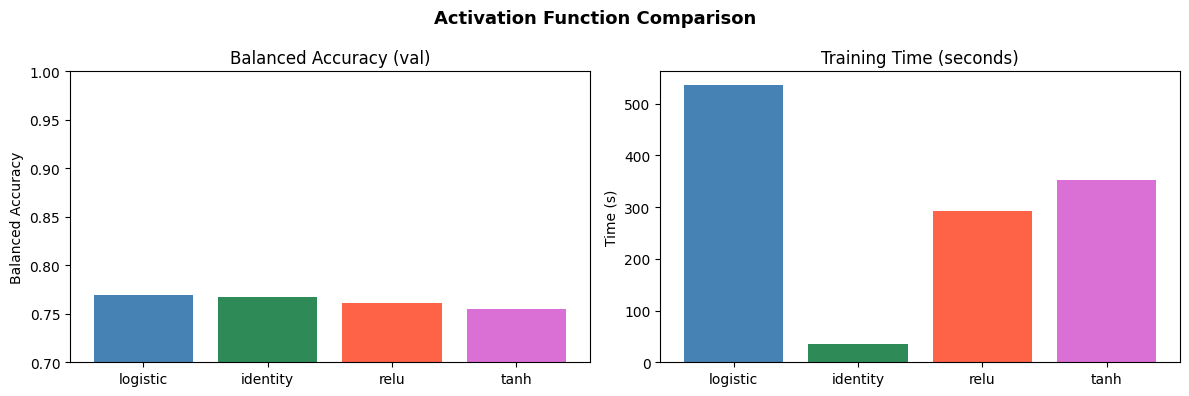

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

colors = ["steelblue", "seagreen", "tomato", "orchid"]

ax1.bar(df_act["activation"], df_act["bacc_val"], color=colors)
ax1.set_title("Balanced Accuracy (val)")
ax1.set_ylabel("Balanced Accuracy")
ax1.set_ylim(0.7, 1.0)  # adjust if needed

ax2.bar(df_act["activation"], df_act["time_s"], color=colors)
ax2.set_title("Training Time (seconds)")
ax2.set_ylabel("Time (s)")

plt.suptitle("Activation Function Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Cost function and backpropagation (conceptual)

### Task
- Inspect the training loss curve
- Relate loss minimization to weight updates

**Reflection**
- How is this similar to gradient descent in regression?


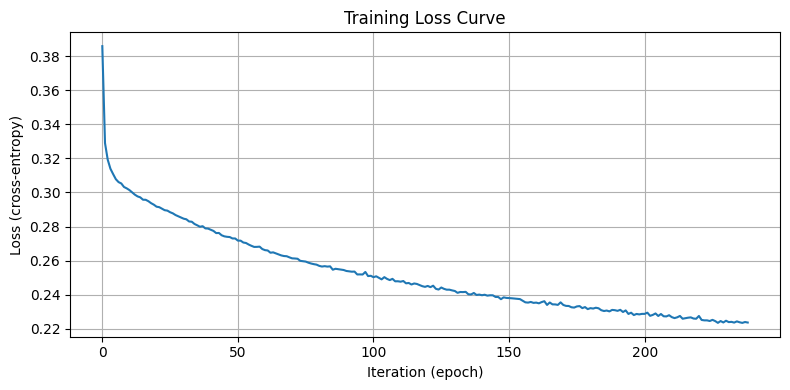

Converged: 239 iterations


In [13]:
# TODO: loss curve inspection
mlp_verbose = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    max_iter=300,
    random_state=42
)

mlp_verbose.fit(X_train_scaled, y_train)

plt.figure(figsize=(8, 4))
plt.plot(mlp_verbose.loss_curve_)
plt.title("Training Loss Curve")
plt.xlabel("Iteration (epoch)")
plt.ylabel("Loss (cross-entropy)")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Converged: {mlp_verbose.n_iter_} iterations")

## 7. Comparison with classical models

### Task
- Compare ANN performance with:
  - Logistic Regression
  - Tree-based models (previous sessions)

**Reflection**
- What is gained and what is lost?


In [ ]:
comparison = {
    "Logistic Regression": balanced_accuracy_score(y_val, y_pred_lr),
    "MLP (relu, 64-32)":   balanced_accuracy_score(y_val, y_pred_mlp),
}

for name, score in comparison.items():
    print(f"{name:30s}: {score:.4f}")

## 8. Critical reflection

Answer in Markdown:
- When are neural networks a good choice?

    - When the data is high-dimensional and unstructured (images, text, audio), when the relationships between features are highly nonlinear and complex, and when you have large amounts of training data to support the number of parameters.

- What are their main risks and limitations?
    - Black box — very hard to interpret which features drive predictions
    - Data hungry — need large datasets to generalise well
    - Computationally expensive — slow to train vs. trees or logistic regression
    - Overfitting — many parameters means high risk without regularisation
Sensitive to hyperparameters — architecture, learning rate, etc. require tuning
- Why are simpler models often preferred in practice?
    - On tabular/structured data, models like Logistic Regression or Gradient Boosting typically match or beat ANNs with far less complexity. They're faster, interpretable, and easier to debug and maintain in production. The added complexity of a neural network is only justified when it brings a clear, measurable benefit.


### Reflection

(Write your answers here.)
